## Classification automatique de la Qualité du vins 

### 1. Chargement et description des données et description des données

### Chargement des données 

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import warnings

#Ignorer les messages warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("winequality-red.csv",delimiter=";",decimal=",")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [255]:
print(X.shape)

(1599, 11)


In [256]:
## Verification pour les valeurs manquantes
X.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

### Statistiques Descriptives

In [258]:
#dimension des données
print("Dimension des données : ", X.shape)

#statistiques descriptives
X.describe()

Dimension des données :  (1599, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


### Commentaires:

- Nous pouvons constater que les variables chloride et density ont des variances très faibles de l'ordre de 0.002 et 0.05 et apporterait peu d'infornation dans ce cas en dehors que nous avons ici du vin rouge.

<AxesSubplot:title={'center':'Distribution de la Qualité des Vins dans le dataset'}, xlabel='quality', ylabel='Density'>

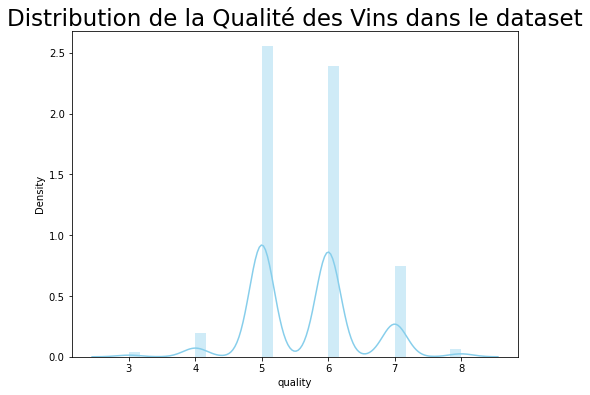

In [259]:
# create a distribution plot of quality
f0, ax = plt.subplots(figsize=(8, 6))
plt.title('Distribution de la Qualité des Vins dans le dataset',fontsize=23)
sns.distplot(df['quality'], color='skyblue')

### Commentaires:

- Nous pouvons constater que la distrbution n'est pas équilibrée. La plus grande quantité des vins de notre dataset se situe dans une qualité de niveau 5, 6, et 7 et peu dans les niveaux de qualité 4 et 8.  


- Nous avons un biais dans les données dès le départ et la discrimination lors de la classification sera plus faible et nous aurons peu être beaucoup de recouvrement.


<AxesSubplot:xlabel='quality', ylabel='residual sugar'>

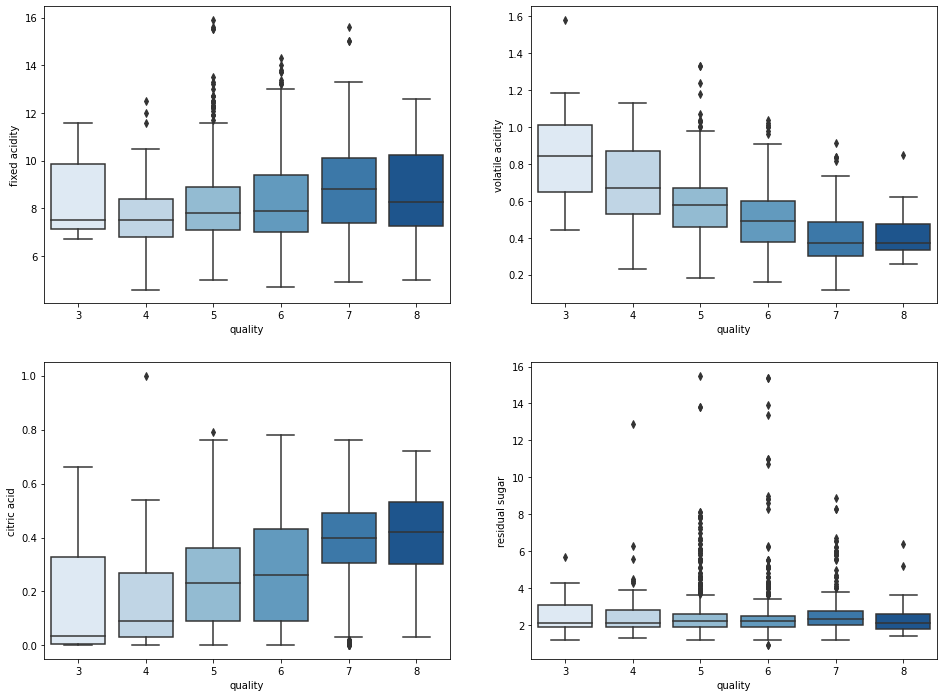

In [260]:
# Génération de box-plot pour les outliers et les prédicteurs possibles

f2, ax = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot('quality', 'fixed acidity', data=df, ax=ax[0, 0], palette='Blues')
sns.boxplot('quality', 'volatile acidity', data=df, ax=ax[0, 1], palette='Blues')
sns.boxplot('quality', 'citric acid', data=df, ax=ax[1, 0], palette='Blues')
sns.boxplot('quality', 'residual sugar', data=df, ax=ax[1, 1], palette='Blues')

### Commentaires:

- plus la valeur de la variable Volatile acidy (acidité volatile) diminue plus le vin rouge semble être de très bonne qualité.

- Plus la valeur de la variable citric acid augmente plus le vin rouge semble être de très bonne qualité


<AxesSubplot:xlabel='quality', ylabel='pH'>

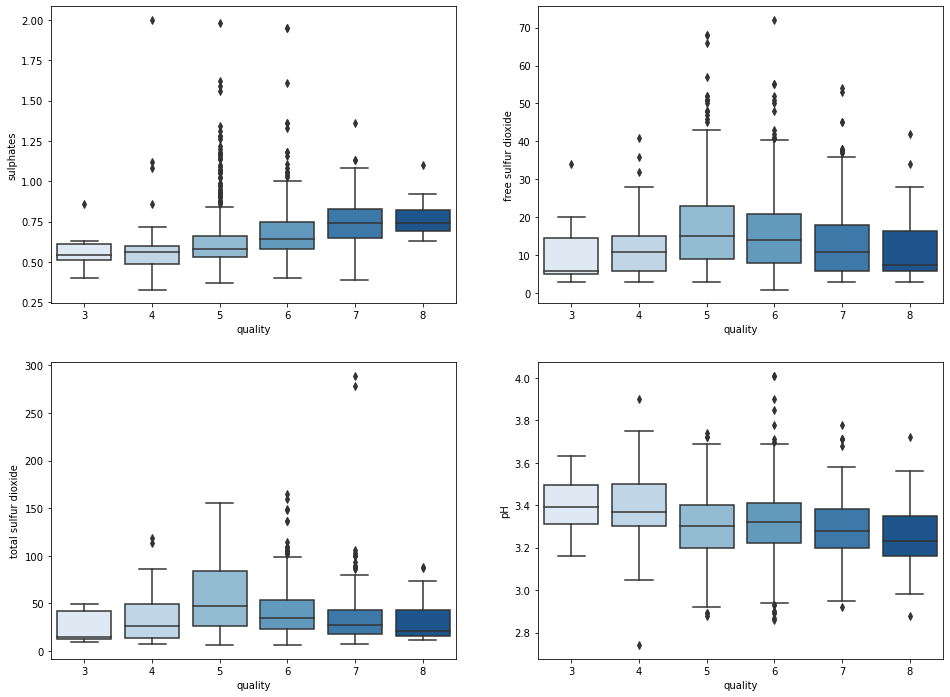

In [261]:
# create box plot for features
f2, ax = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot('quality', 'sulphates', data=df, ax=ax[0, 0], palette='Blues')
sns.boxplot('quality', 'free sulfur dioxide', data=df, ax=ax[0, 1], palette='Blues')
sns.boxplot('quality', 'total sulfur dioxide', data=df, ax=ax[1, 0], palette='Blues')
sns.boxplot('quality', 'pH', data=df, ax=ax[1, 1], palette='Blues')


### Commentaires:

- Plus la valeur de la variable pH diminue plus le vin rouge semble être de très bonne qualité. Dans ce cas il faudra faire une ANOVA pour s'assurer de la significativité de la variable.

- Plus la valeur de la variable sulfates augmente plus le vin rouge semble être de très bonne qualité

<AxesSubplot:xlabel='quality', ylabel='alcohol'>

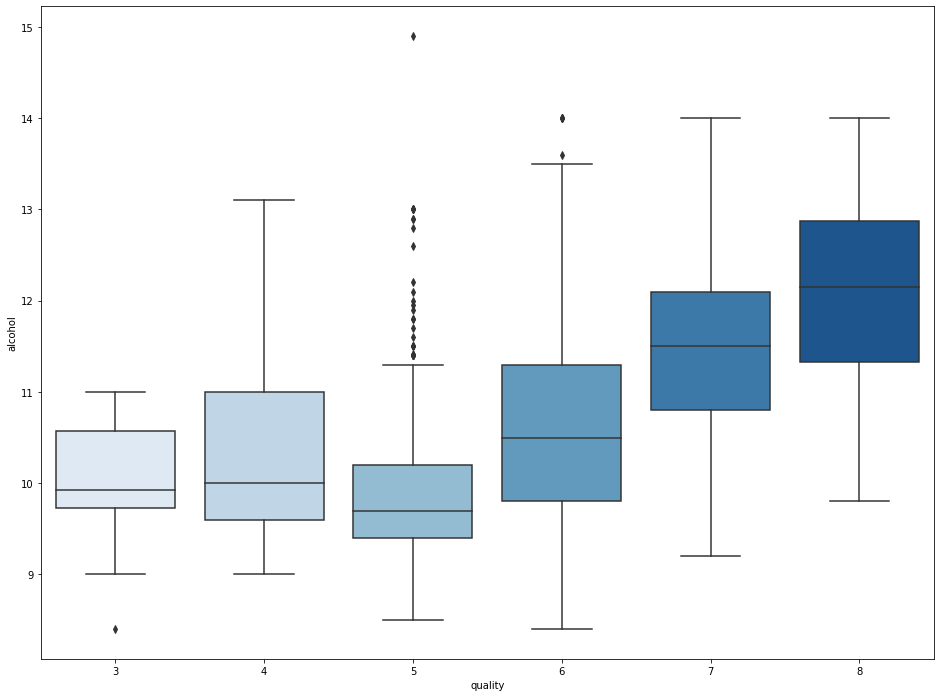

In [262]:
# create box plot for features
f2, ax = plt.subplots(1, 1, figsize=(16, 12))
sns.boxplot('quality', 'alcohol', data=df, ax=ax, palette='Blues')

### Commentaires: 

- Nous pouvons constater que les vins rouges ayant plus d'alcool sont de meilleurs qualité.



Remarque générale: il y a de nombreus outliers dans les distributions.

array([[<AxesSubplot:xlabel='fixed acidity', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='volatile acidity', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='citric acid', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='residual sugar', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='chlorides', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='free sulfur dioxide', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='total sulfur dioxide', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='density', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='pH', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='sulphates', ylabel='fixed acidity'>,
        <AxesSubplot:xlabel='alcohol', ylabel='fixed acidity'>],
       [<AxesSubplot:xlabel='fixed acidity', ylabel='volatile acidity'>,
        <AxesSubplot:xlabel='volatile acidity', ylabel='volatile acidity'>,
        <AxesSubplot:xlabel='citric acid', ylabel='volatile acidity'>,
        <AxesSubplot:xlab

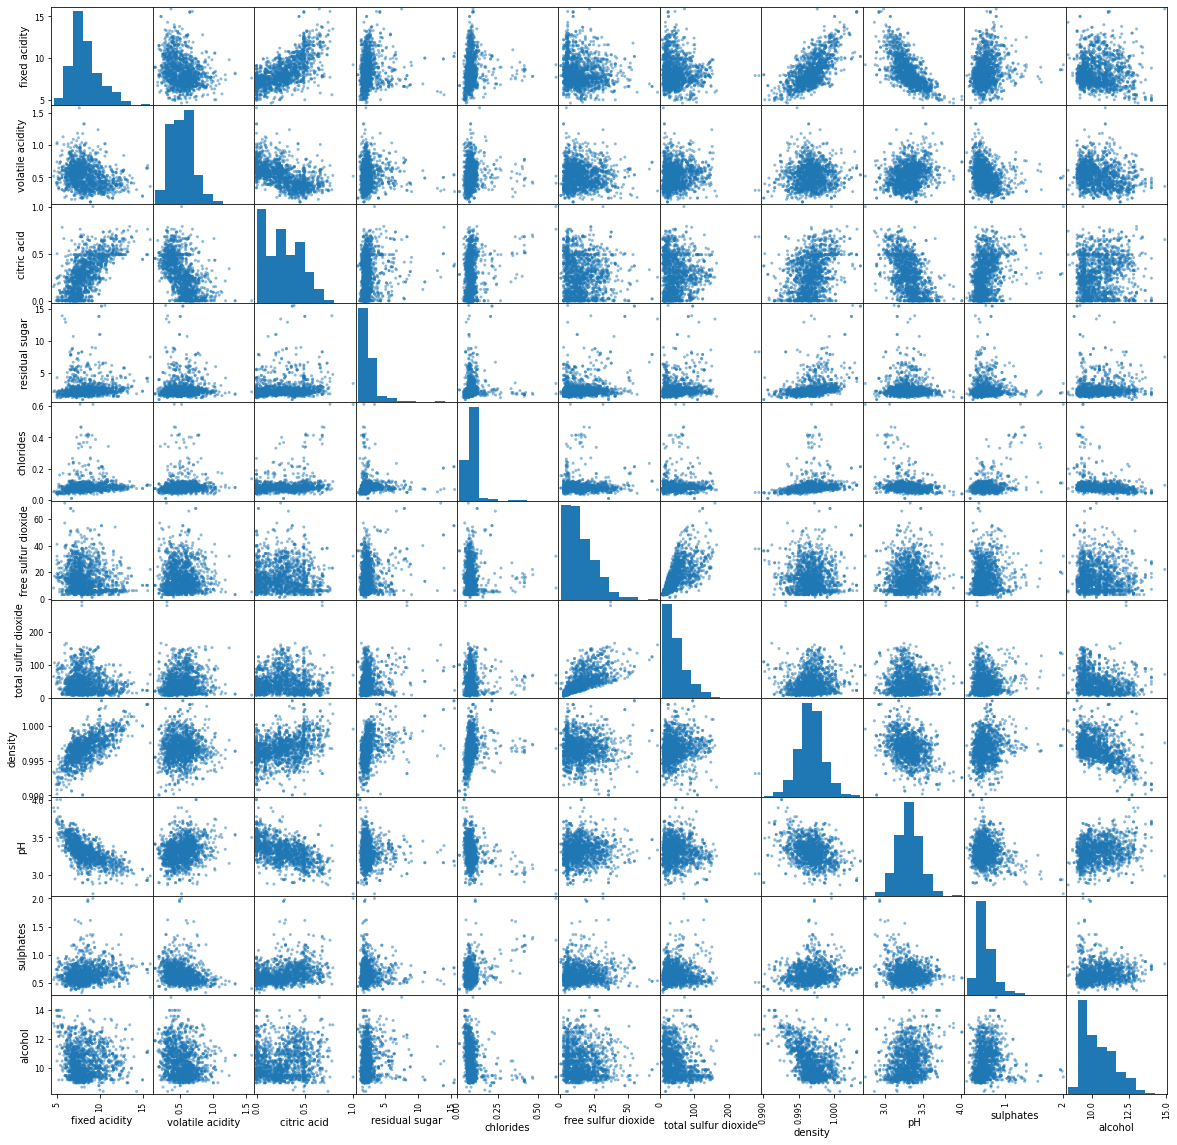

In [263]:
#graphique - croisement deux à deux des variables
df_ = pd.DataFrame(X)
pd.plotting.scatter_matrix(df_,figsize=(20,20))

### Commentaires:

- relation statistique possible entre la variable fixed acid et les varariables pH, density, citric acid

- relation statistique volatile acidity et citric acid


In [265]:
X = df.set_index(['quality'])
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
5,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
5,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
6,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


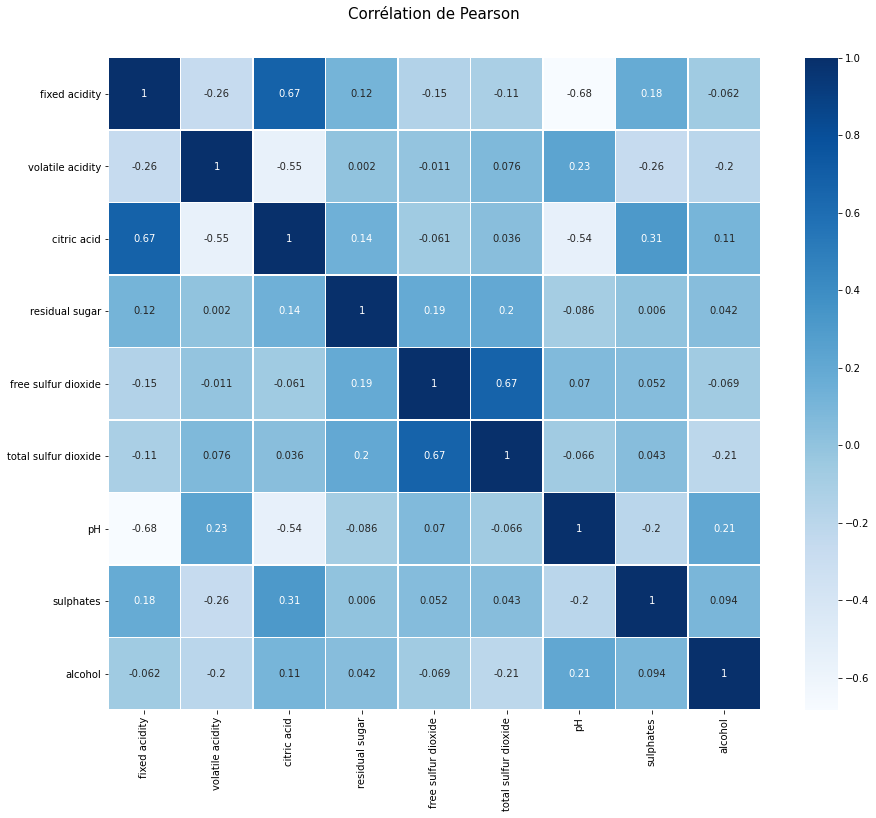

In [400]:
#Matrice de correlation
corr=X.corr(method="pearson")
corr=corr.round(3)
f,ax = plt.subplots(figsize=(16,12))
cmap = sns.diverging_palette(220,10,as_cmap=True)
sns.heatmap(corr, cmap="Blues", square=True, ax=ax, annot=True, linewidth=0.5)
plt.title('Corrélation de Pearson',y=1.05, size=15)

plt.show()

### Commentaires: 

pas de PCA dans notre cas.



## 2. Classification automatique 

### 2.1 Classification automatique sans réduction de dimensions

#### Mise à l'échelle du dataset

In [323]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(data=X_scaled)

### Classification automatique avec la méthode du K-means

In [324]:
from sklearn.cluster import KMeans
from sklearn import metrics 

res=[] 
wcss=[]

range_n_cluster = range(2,10)
for k in range_n_cluster:   
    km = KMeans(n_clusters=k) 
    km.fit(X_scaled) 
    res.append(metrics.silhouette_score(X_scaled,km.labels_) )
    wcss.append(km.inertia_)
    km.labels_
    cluster_labels = km.fit_predict(X_scaled)
    cluster_labels

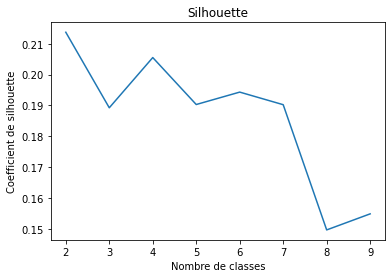

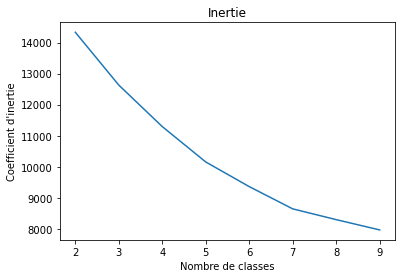

In [325]:
#plot nb. clusters vs. silhouette score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),res) 
plt.title("Silhouette")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient de silhouette")
plt.show() 

#plot nb. clusters vs. Inertie score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),wcss) 
plt.title("Inertie")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient d'inertie")
plt.show() 

### Conclusion:


- Il faut que le coefficient de sillouette soit maximal et l'inertie minimale. Dans notre cas, cela coresspond à 4 classes donc 4 regroupemenst ou clusters. Nous prendrons 4 clusters car l'inertie est minimale.


- Notons que le coefficient de silloutte est son maximun atteint est de 0.23

In [368]:
#k-means sur les données centrées et réduites
from sklearn import cluster
kmeans = cluster.KMeans(n_clusters=4)
kmeans.fit(X_scaled)

coord=kmeans.fit_transform(X_scaled)
coordo=coord

#index triés des groupes
idk = np.argsort(kmeans.labels_)

#affichage des observations et leurs groupes
g_ = pd.DataFrame(X.index[idk],kmeans.labels_[idk], )
g_


,quality
0,6
0,7
0,6
0,8
0,7
...,...
3,6
3,7
3,6
3,5


In [369]:
g_.loc[0]

,quality
0,6
0,7
0,6
0,8
0,7
...,...
0,7
0,6
0,6
0,6


In [370]:
g_.loc[1]

,quality
1,6
1,7
1,7
1,7
1,7
...,...
1,5
1,6
1,5
1,6


In [371]:
g_.loc[2]

,quality
2,6
2,5
2,5
2,5
2,6
2,5
2,5
2,5
2,5
2,7


In [362]:
g_.loc[3]

,quality
3,6
3,5
3,6
3,6
3,5
...,...
3,5
3,6
3,6
3,5


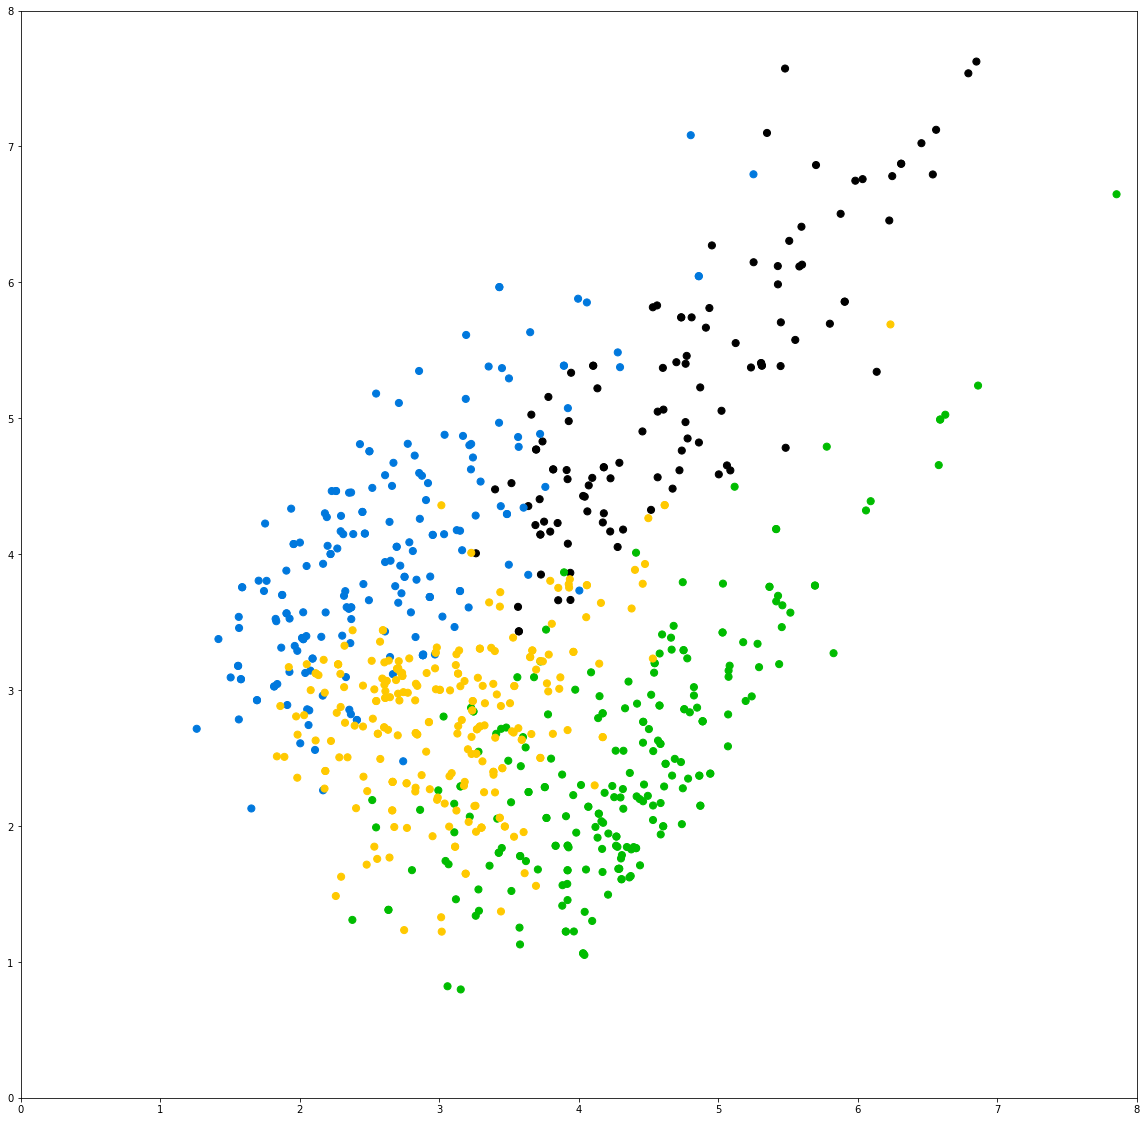

In [327]:
import matplotlib.cm as cm

f,ax = plt.subplots(figsize=(20,20))

ax.set_xlim(0,8)
ax.set_ylim(0,8)
n = X.shape[0]

colors = cm.nipy_spectral(cluster_labels/4)

# Traçage du nuage de points
for k in range(4):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coordo[is_kth_cluster,1],coordo[is_kth_cluster,0],c=colors[is_kth_cluster],s=50)
    
plt.show() 

In [328]:
# K-Means. Validation
from sklearn import metrics as metrics
  
metrics.davies_bouldin_score(X_scaled, cluster_labels==2)

1.500704650373114

### Retirer la variable chloride et density

In [372]:
df = pd.read_csv("winequality-red.csv",delimiter=";",decimal=",")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [373]:
df_ = df.drop(["chlorides","density"], axis =1)

In [374]:
df_.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,11.0,34.0,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,25.0,67.0,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,15.0,54.0,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,17.0,60.0,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,11.0,34.0,3.51,0.56,9.4,5


In [375]:
X = df_.set_index(['quality'])
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol
quality,,,,,,,,,
5,7.4,0.70,0.00,1.9,11.0,34.0,3.51,0.56,9.4
5,7.8,0.88,0.00,2.6,25.0,67.0,3.20,0.68,9.8
5,7.8,0.76,0.04,2.3,15.0,54.0,3.26,0.65,9.8
6,11.2,0.28,0.56,1.9,17.0,60.0,3.16,0.58,9.8
5,7.4,0.70,0.00,1.9,11.0,34.0,3.51,0.56,9.4


In [380]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(data=X_scaled)

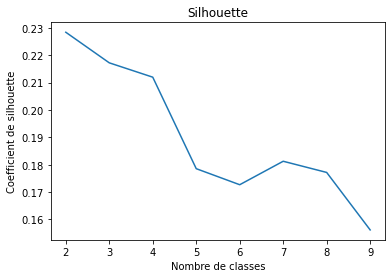

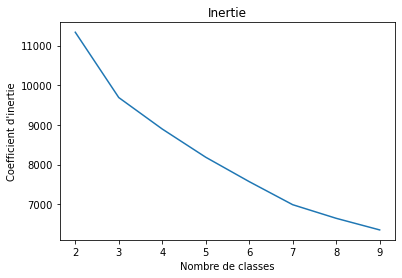

In [381]:
from sklearn.cluster import KMeans
from sklearn import metrics 

res=[] 
wcss=[]

range_n_cluster = range(2,10)
for k in range_n_cluster:   
    km = KMeans(n_clusters=k) 
    km.fit(X_scaled) 
    res.append(metrics.silhouette_score(X_scaled,km.labels_) )
    wcss.append(km.inertia_)
    km.labels_
    cluster_labels = km.fit_predict(X_scaled)
    cluster_labels

#plot nb. clusters vs. silhouette score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),res) 
plt.title("Silhouette")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient de silhouette")
plt.show() 

#plot nb. clusters vs. Inertie score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),wcss) 
plt.title("Inertie")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient d'inertie")
plt.show() 

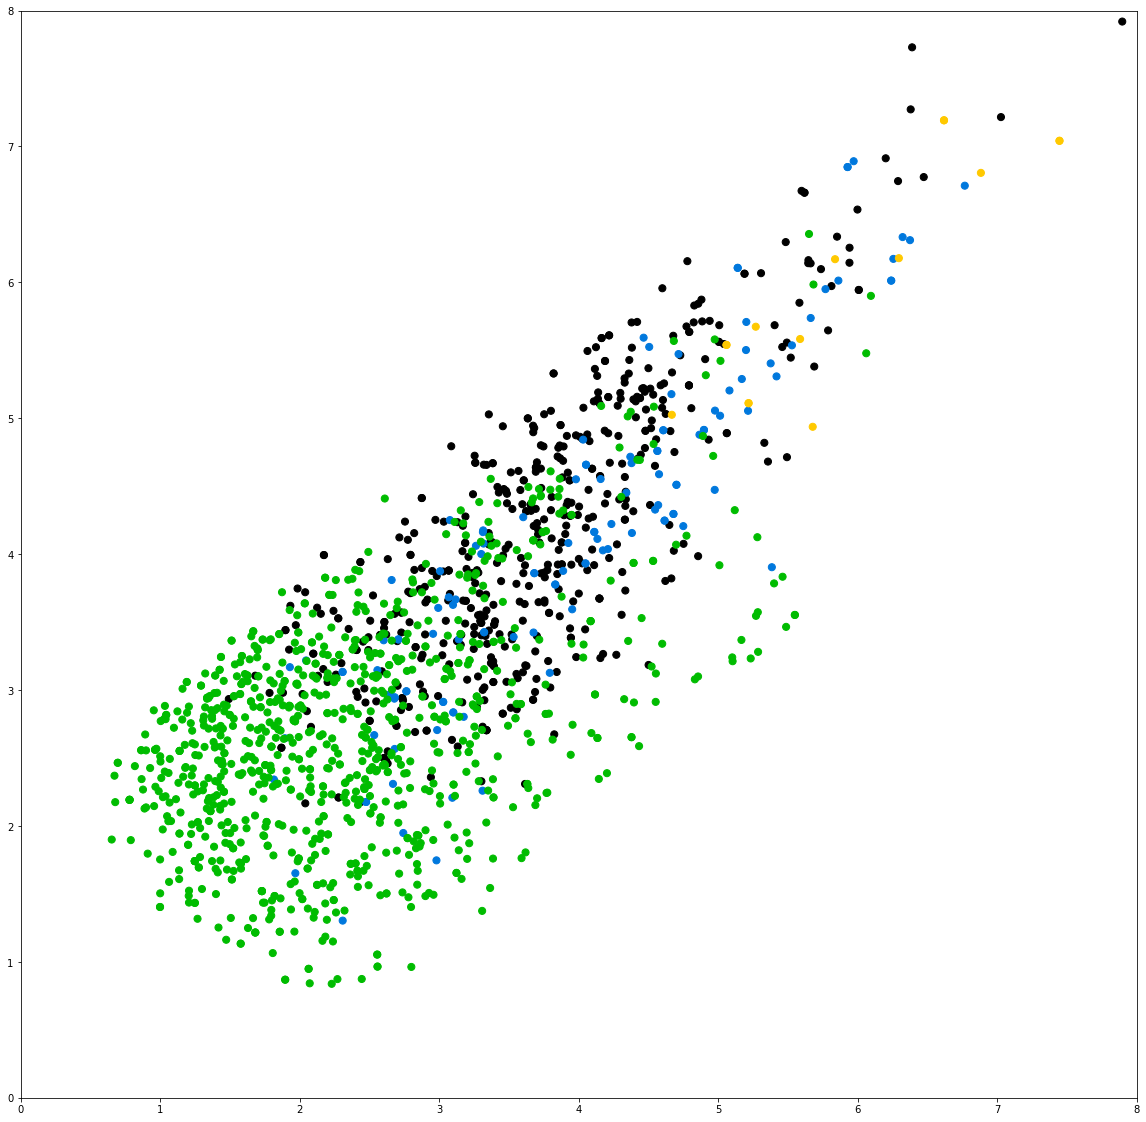

In [439]:
#k-means sur les données centrées et réduites
from sklearn import cluster
kmeans = cluster.KMeans(n_clusters=4)
kmeans.fit(X_scaled)

coord=kmeans.fit_transform(X_scaled)
coordo=coord

#index triés des groupes
idk = np.argsort(kmeans.labels_)

#affichage des observations et leurs groupes
pd.DataFrame(X.index[idk],kmeans.labels_[idk])

import matplotlib.cm as cm

f,ax = plt.subplots(figsize=(20,20))

ax.set_xlim(0,8)
ax.set_ylim(0,8)
n = X.shape[0]

colors = cm.nipy_spectral(cluster_labels/4)

# Traçage du nuage de points
for k in range(4):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coordo[is_kth_cluster,1],coordo[is_kth_cluster,0],c=colors[is_kth_cluster],s=50)
    
plt.show() 

In [393]:
# K-Means. Validation
from sklearn import metrics as metrics
  
metrics.davies_bouldin_score(X_scaled, cluster_labels==2)

2.5775986716196333

pire clasification

In [394]:
#k-means sur les données centrées et réduites
from sklearn import cluster
kmeans = cluster.KMeans(n_clusters=3)
kmeans.fit(X_scaled)

coord=kmeans.fit_transform(X_scaled)
coordo=coord

#index triés des groupes
idk = np.argsort(kmeans.labels_)

#affichage des observations et leurs groupes
groupes = pd.DataFrame(X.index[idk],kmeans.labels_[idk])
groupes

#distances aux centres de classes des observations
#print(kmeans.transform(X_scaled))

,quality
0,6
0,7
0,7
0,7
0,6
...,...
2,7
2,5
2,5
2,5


In [395]:
groupes.loc[0]

,quality
0,6
0,7
0,7
0,7
0,6
...,...
0,7
0,7
0,7
0,6


In [396]:
groupes.loc[1]

,quality
1,6
1,5
1,6
1,5
1,6
...,...
1,5
1,5
1,5
1,5


In [398]:
groupes.loc[2]

,quality
2,5
2,5
2,5
2,5
2,5
...,...
2,7
2,5
2,5
2,5


### Commentaires:


- Cluster 1: vin de bonne qualité
- Clsuter 2: vin de moyenne qualité
- Cluster 3: vin de basse qualité

In [408]:
df = pd.read_csv("winequality-red.csv",delimiter=";",decimal=",")
df.head(10)
X = df_.set_index(['quality'])
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol
quality,,,,,,,,,
5,7.4,0.70,0.00,1.9,11.0,34.0,3.51,0.56,9.4
5,7.8,0.88,0.00,2.6,25.0,67.0,3.20,0.68,9.8
5,7.8,0.76,0.04,2.3,15.0,54.0,3.26,0.65,9.8
6,11.2,0.28,0.56,1.9,17.0,60.0,3.16,0.58,9.8
5,7.4,0.70,0.00,1.9,11.0,34.0,3.51,0.56,9.4


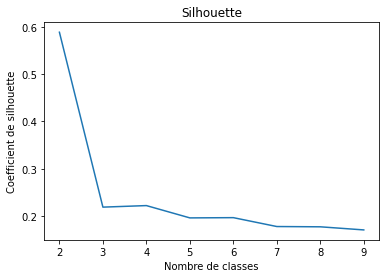

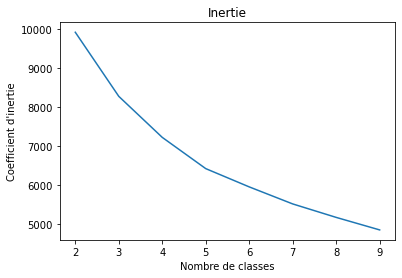

In [415]:
# utilisation de RobustScaler

from sklearn.preprocessing import RobustScaler
X_scaled = RobustScaler().fit_transform(X)
X_scaled = pd.DataFrame(data=X_scaled)


from sklearn.cluster import KMeans
from sklearn import metrics 

res=[] 
wcss=[]

range_n_cluster = range(2,10)
for k in range_n_cluster:   
    km = KMeans(n_clusters=k) 
    km.fit(X_scaled) 
    res.append(metrics.silhouette_score(X_scaled,km.labels_) )
    wcss.append(km.inertia_)
    km.labels_
    cluster_labels = km.fit_predict(X_scaled)
    cluster_labels

#plot nb. clusters vs. silhouette score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),res) 
plt.title("Silhouette")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient de silhouette")
plt.show() 

#plot nb. clusters vs. Inertie score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,10,1),wcss) 
plt.title("Inertie")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient d'inertie")
plt.show() 

### Conclusion:


- Il faut que le coefficient de sillouette soit maximal et l'inertie minimale. Dans notre cas, cela coresspond à 3 classes donc 4 regroupemenst ou clusters. Nous prendrons 3 clusters car l'inertie est minimale.


- Notons que le coefficient de silloutte est son maximun atteint est de 0.72

In [440]:
#k-means sur les données centrées et réduites
from sklearn import cluster
kmeans = cluster.KMeans(n_clusters=4)
kmeans.fit(X_scaled)

coord=kmeans.fit_transform(X_scaled)
coordo=coord

#index triés des groupes
idk = np.argsort(kmeans.labels_)

#affichage des observations et leurs groupes
groupes = pd.DataFrame(X.index[idk],kmeans.labels_[idk])
groupes

#distances aux centres de classes des observations
#print(kmeans.transform(X_scaled))

,quality
0,5
0,6
0,5
0,6
0,6
...,...
3,6
3,6
3,5
3,6


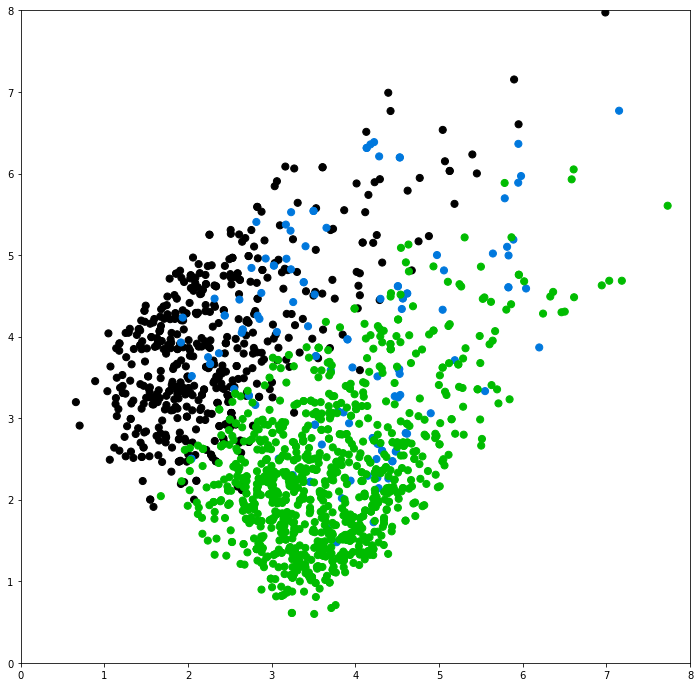

In [441]:
import matplotlib.cm as cm

f,ax = plt.subplots(figsize=(12,12))

ax.set_xlim(0,8)
ax.set_ylim(0,8)
n = X.shape[0]

colors = cm.nipy_spectral(cluster_labels/4)

# Traçage du nuage de points
for k in range(3):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coordo[is_kth_cluster,1],coordo[is_kth_cluster,0],c=colors[is_kth_cluster],s=50)
    
plt.show() 

In [418]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

km = KMeans(n_clusters=4) 
km.fit(X_scaled) 
km.labels_
cluster_labels = km.fit_predict(X_scaled)
cluster_labels

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

In [419]:
# K-Means. Validation
from sklearn import metrics as metrics
  
metrics.davies_bouldin_score(X_scaled, cluster_labels==2)

2.065200780067836

pire indice

### 2.2  Classification automatique avec l' algorithme du K-Medoïde 

In [420]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(data=X_scaled)


import sklearn_extra 
from sklearn_extra.cluster import KMedoids
from sklearn import metrics 

res=[] 
wcss=[]

range_n_cluster = range(2,8)
for k in range_n_cluster:   
    km2 = sklearn_extra.cluster.KMedoids(n_clusters=k) 
    km2.fit(coord) 
    res.append(metrics.silhouette_score(coord,km2.labels_) )
    wcss.append(km2.inertia_)

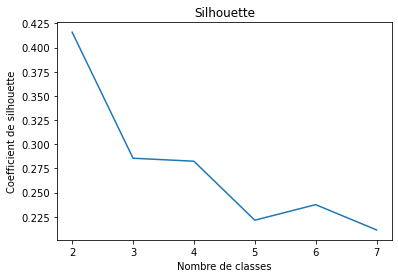

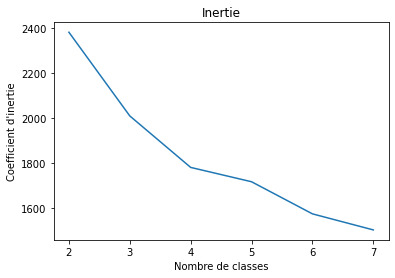

In [421]:
#plot nb. clusters vs. silhouette score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,8,1),res) 
plt.title("Silhouette")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient de silhouette")
plt.show() 

#plot nb. clusters vs. Inertie score 
import matplotlib.pyplot as plt 
plt.plot(np.arange(2,8,1),wcss) 
plt.title("Inertie")
plt.xlabel("Nombre de classes")
plt.ylabel("Coefficient d'inertie")
plt.show() 

In [422]:
#k-means sur les données centrées et réduites

kmedoids = KMedoids(n_clusters=3)
kmedoids.fit(X_scaled)

coord=kmedoids.fit_transform(X_scaled)
coordo=coord

#index triés des groupes
idk = np.argsort(kmedoids.labels_)

#affichage des observations et leurs groupes
gr_= pd.DataFrame(X.index[idk],kmedoids.labels_[idk])

gr_
#distances aux centres de classes des observations
#print(kmedoids.transform(X_scaled))

,quality
0,6
0,7
0,6
0,5
0,5
...,...
2,6
2,7
2,6
2,5


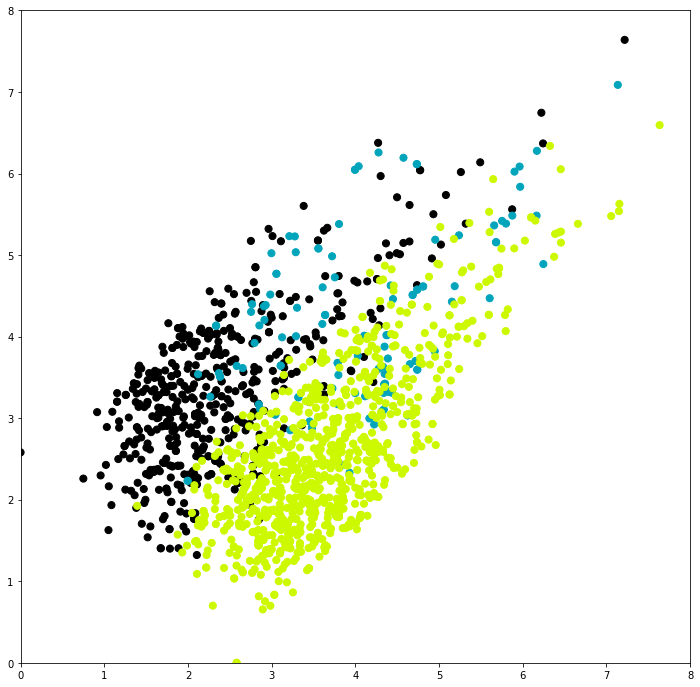

In [423]:
import matplotlib.cm as cm

f,ax = plt.subplots(figsize=(12,12))

ax.set_xlim(0,8)
ax.set_ylim(0,8)
n = X.shape[0]

colors = cm.nipy_spectral(cluster_labels/3)

# Traçage du nuage de points
for k in range(3):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coordo[is_kth_cluster,1],coordo[is_kth_cluster,0],c=colors[is_kth_cluster],s=50)
    
plt.show() 

In [424]:
# K-Means. Validation
from sklearn import metrics as metrics
  
metrics.davies_bouldin_score(X_scaled, cluster_labels==2)

2.0183670032155776

pire indice

In [350]:
g0 = gr_.loc[0]
g0

,quality
0,6
0,5
0,7
0,5
0,5
...,...
0,5
0,5
0,5
0,6


In [351]:
g1 = gr_.loc[1]
g1

,quality
1,7
1,7
1,5
1,7
1,5
...,...
1,5
1,4
1,6
1,6


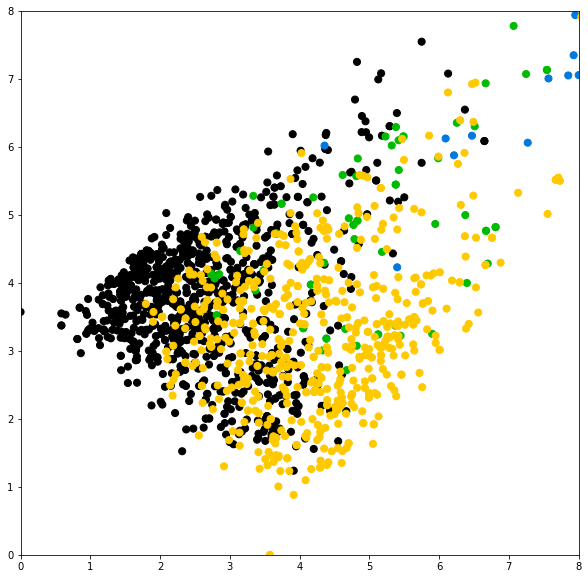

In [340]:
import matplotlib.cm as cm


f,ax = plt.subplots(figsize=(10,10))

ax.set_xlim(0,8)
ax.set_ylim(0,8)
n = X.shape[0]

colors = cm.nipy_spectral(cluster_labels/4)

# Traçage du nuage de points
for k in range(4):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coordo[is_kth_cluster,1],coordo[is_kth_cluster,0],c=colors[is_kth_cluster],s=50)
    
plt.show() 

### Commentaires:

- Nous obtenons les mêmes résultats que dans le cas de l'algorithme kmean, soit 4 clusters aussi

### 2.3 Classification automatique par algorithme du regroupements hierarchiques sans réduction de dimension

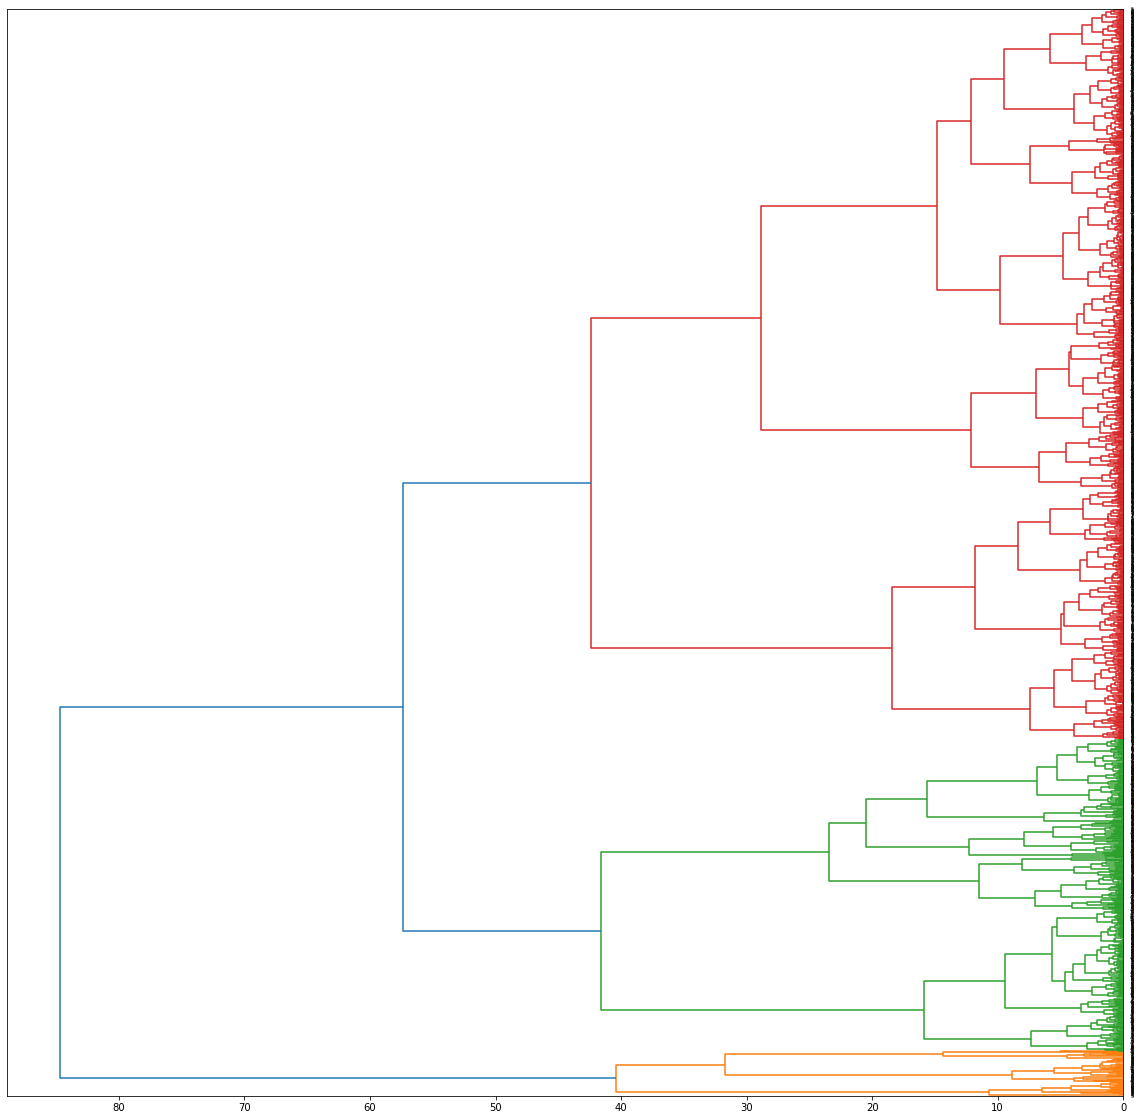

In [354]:
#librairies pour la CAH
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

#générer la matrice des liens
Z = linkage(coord,method='ward',metric='euclidean')

#affichage du dendrogramme
plt.figure(figsize=(20, 20))
dendrogram(Z,labels=X.index,orientation='left',color_threshold= 45)

plt.show()

- La méthode de Ward est en fait une méthode qui tente de minimiser la variance au sein de chaque cluster. Nous voulons minimiser les variantes intra-cluster. C'est la variance au sein de chaque grappe.





**Comment déterminer le nombre optimal de clusters à partir de ce diagramme?**




- Nous recherchons la plus grande distance que nous pouvons verticalement sans croiser de ligne horizontale et celle-ci est la ligne encadrée rouge sur le diagramme ci-dessus. Comptons le nombre de lignes sur le diagramme et déterminons le nombre optimal de clusters. Le nombre de cluster sera 4 pour cet ensemble de données.  

Dans notre cas notre cutoff est t=40. 

In [343]:
from scipy.cluster.hierarchy import fcluster

#cutoff t = 7.5 ==> 4 groupes obtenus
groupes_cah = fcluster(Z,t = 40, criterion = "distance")

#index tris des groupes
idg = np.argsort(groupes_cah)

#affichage des observations et leurs groupes
pd.DataFrame(X.index[idg],groupes_cah[idg])

,quality
1,6
1,6
1,6
1,5
1,6
...,...
5,5
5,7
5,6
5,6


### Conclusion: 

Nous obtenons le même nombre de cluster soit 3 qu'avec les algorithmes K-Means et CAH et que les caractéristiques physicochimique sont: sulfate, pH, acide citrique, acidité volatile 

### 4. Règles d'associations

In [425]:
df = pd.read_csv("winequality-red.csv",delimiter=";",decimal=",")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [426]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


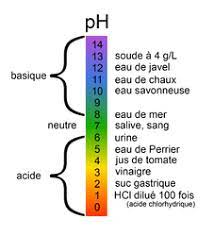


In [427]:
# Définit une fonction générique en utilisant la fonction replace de Pandas
def coding(col, codeDict):
    colCoded = col #pd.Series(col, copy=True)
    for key, value in codeDict.items():
        colCoded.replace(key, value, inplace=True)
    return colCoded

In [428]:
CodeQuality = {1:'VLQ',
               2:'VLQ',
               3:'LQ',
               4:'LQ',
               5:'MQ',
               6:'MQ',
               7:'HQ',
               8:'HQ',
               9:'VHQ'}


In [429]:
def coding(col,codeDict):
    for key, value in codeDict.items():
        col.replace(key, value, inplace=True)
    return col


def coding_ph(col):
    
    for i in range(len(col)):
        if col[i] > 7:
            col[i] = "Base"
        elif col[i] == 7:
            col[i] = "Neutre"
        else:
            col[i] = "Acid"
            
    return col

In [430]:
df['quality']= coding(df.quality,CodeQuality)

In [431]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,MQ
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,MQ
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,MQ
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,MQ
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,MQ


In [437]:
def pH_coding(col):
    for i in range(len(col)):
        if col[i] == 7:
            col[i] = "pH_Neutre"
            if col[i] < 7 :
                col[i] = "pH_Acid"
            else:
                col[i] = "pH_Base"

In [438]:
pH_coding(df["pH"])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,MQ
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,MQ
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,MQ
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,MQ
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,MQ


In [434]:
df.pH[500]

3.43

In [435]:
col = df.pH


In [436]:
df.pH

0       3.51
1       3.20
2       3.26
3       3.16
4       3.51
        ... 
1594    3.45
1595    3.52
1596    3.42
1597    3.57
1598    3.39
Name: pH, Length: 1599, dtype: float64

In [230]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,Acid,0.56,9.4,MQ
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,Acid,0.68,9.8,MQ
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,Acid,0.65,9.8,MQ
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,Acid,0.58,9.8,MQ
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,Acid,0.56,9.4,MQ


In [401]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Avoir une conversation ouverte avec la prof.

### Dans le cas d'un recodage catégorielle ou nominal afin de procéder à appliquer les règle d'association. il faudrait en discuter avec l'expert métier. Par exemple connaître les limites ou les quantité légales de l'alcool, acide citrique, etc..